In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("healthcare_data.csv")

In [7]:
df.head()


,patient_id,first_name,last_name,age,gender,phone,email,department,diagnosis,treatment,admission_date,discharge_date,status,bill_amount
0,PID1000,Victor,Hoffman,60,Male,578-267-5326x77210,turnermichelle@example.org,Pediatrics,Migraine,Medication,2024-02-10,2025-06-01,Admitted,100900.97
1,PID1001,John,Sparks,11,Other,(263)977-2102x55652,amandagarner@example.net,Dermatology,Diabetes,Medication,2023-11-18,2025-01-26,Discharged,120905.91
2,PID1002,Isabella,Rubio,2,Female,275.597.9494,james75@example.org,Neurology,Asthma,Medication,2023-12-04,2025-03-02,Under Treatment,170672.18
3,PID1003,Allison,Hill,22,Other,4857130035,salazaralice@example.net,Cardiology,Cancer,Observation,2023-12-25,2024-10-07,Discharged,149977.74
4,PID1004,James,Berry,8,Female,791-362-4064,christinaalexander@example.net,Neurology,Cancer,Observation,2025-02-14,2024-11-15,Under Treatment,160039.43


In [8]:
df.shape

(17498, 14)

In [9]:
df.columns

Index(['patient_id', 'first_name', 'last_name', 'age', 'gender', 'phone',
       'email', 'department', 'diagnosis', 'treatment', 'admission_date',
       'discharge_date', 'status', 'bill_amount'],
      dtype='str')

In [10]:
df.info

<bound method DataFrame.info of       patient_id first_name last_name  age  gender                phone  \
0        PID1000     Victor   Hoffman   60    Male   578-267-5326x77210   
1        PID1001       John    Sparks   11   Other  (263)977-2102x55652   
2        PID1002   Isabella     Rubio    2  Female         275.597.9494   
3        PID1003    Allison      Hill   22   Other           4857130035   
4        PID1004      James     Berry    8  Female         791-362-4064   
...          ...        ...       ...  ...     ...                  ...   
17493   PID18493   Patricia     Bates   31    Male     001-505-697-3292   
17494   PID18494      Ethan    Jensen   81   Other         434-983-8764   
17495   PID18495     Steven   Barrett   59  Female         274-486-1625   
17496   PID18496      Nancy      Moss   31    Male        (609)859-0475   
17497   PID18497      Aaron    Pierce   42   Other   543.685.8964x09860   

                                email        department diagnosis  

In [11]:
df.describe()

,age,bill_amount
count,17498.000000,17498.000000
mean,45.426449,100716.900625
std,25.993349,57619.407262
min,1.000000,2009.660000
25%,23.000000,50677.667500
50%,45.000000,100044.505000
75%,68.000000,151204.307500
max,90.000000,199991.660000


In [12]:
df.nunique()

patient_id        17498
first_name          679
last_name          1000
age                  90
gender                3
phone             17498
email             16880
department            7
diagnosis             8
treatment             5
admission_date      731
discharge_date      366
status                3
bill_amount       17489
dtype: int64

In [13]:
df['email'].value_counts().loc[lambda x:x>1]

email
yjohnson@example.org           6
osmith@example.net             6
nsmith@example.org             4
fjohnson@example.org           3
zbrown@example.org             3
                              ..
elizabethwagner@example.net    2
fdavis@example.net             2
shunter@example.com            2
jasonhamilton@example.net      2
nanderson@example.com          2
Name: count, Length: 566, dtype: int64

In [14]:
df['email'].duplicated().sum()

np.int64(618)

In [15]:
duplicate_email=df[df['email'].duplicated(keep=False)].sort_values('email')
duplicate_email[[
    'patient_id',
    'first_name',
    'last_name',
    'email'
]]

,patient_id,first_name,last_name,email
4039,PID5039,Michael,Henson,aanderson@example.net
15256,PID16256,Benjamin,Jefferson,aanderson@example.net
11445,PID12445,Ryan,Duran,abrown@example.net
11746,PID12746,Cory,Adams,abrown@example.net
13474,PID14474,Jacqueline,Golden,abrown@example.net
...,...,...,...,...
17320,PID18320,Matthew,Rice,zsmith@example.net
1012,PID2012,Mark,Chambers,ztaylor@example.net
14137,PID15137,Benjamin,Lindsey,ztaylor@example.net
4425,PID5425,Nicholas,Ramos,zweeks@example.org


In [16]:
df['email_quality']=np.where(
    df['email'].duplicated(keep=False),
    "Duplicate Email",
    "Unique Email")

In [17]:
df.head()

,patient_id,first_name,last_name,age,gender,phone,email,department,diagnosis,treatment,admission_date,discharge_date,status,bill_amount,email_quality
0,PID1000,Victor,Hoffman,60,Male,578-267-5326x77210,turnermichelle@example.org,Pediatrics,Migraine,Medication,2024-02-10,2025-06-01,Admitted,100900.97,Unique Email
1,PID1001,John,Sparks,11,Other,(263)977-2102x55652,amandagarner@example.net,Dermatology,Diabetes,Medication,2023-11-18,2025-01-26,Discharged,120905.91,Unique Email
2,PID1002,Isabella,Rubio,2,Female,275.597.9494,james75@example.org,Neurology,Asthma,Medication,2023-12-04,2025-03-02,Under Treatment,170672.18,Duplicate Email
3,PID1003,Allison,Hill,22,Other,4857130035,salazaralice@example.net,Cardiology,Cancer,Observation,2023-12-25,2024-10-07,Discharged,149977.74,Unique Email
4,PID1004,James,Berry,8,Female,791-362-4064,christinaalexander@example.net,Neurology,Cancer,Observation,2025-02-14,2024-11-15,Under Treatment,160039.43,Unique Email


In [18]:
df.isnull.sum()

AttributeError: 'function' object has no attribute 'sum'

In [19]:
df.isnull().sum()


patient_id        0
first_name        0
last_name         0
age               0
gender            0
phone             0
email             0
department        0
diagnosis         0
treatment         0
admission_date    0
discharge_date    0
status            0
bill_amount       0
email_quality     0
dtype: int64

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17498 entries, 0 to 17497
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      17498 non-null  str    
 1   first_name      17498 non-null  str    
 2   last_name       17498 non-null  str    
 3   age             17498 non-null  int64  
 4   gender          17498 non-null  str    
 5   phone           17498 non-null  str    
 6   email           17498 non-null  str    
 7   department      17498 non-null  str    
 8   diagnosis       17498 non-null  str    
 9   treatment       17498 non-null  str    
 10  admission_date  17498 non-null  str    
 11  discharge_date  17498 non-null  str    
 12  status          17498 non-null  str    
 13  bill_amount     17498 non-null  float64
 14  email_quality   17498 non-null  str    
dtypes: float64(1), int64(1), str(13)
memory usage: 4.2 MB


In [21]:
df['admission_date']=pd.to_datetime(df['admission_date'])
df['discharge_date']=pd.to_datetime(df['discharge_date'])

In [22]:
df['Length of stay']=(df['discharge_date']-df['admission_date']).dt.days

In [23]:
df.head(10)

,patient_id,first_name,last_name,age,gender,phone,email,department,diagnosis,treatment,admission_date,discharge_date,status,bill_amount,email_quality,Length of stay
0,PID1000,Victor,Hoffman,60,Male,578-267-5326x77210,turnermichelle@example.org,Pediatrics,Migraine,Medication,2024-02-10,2025-06-01,Admitted,100900.97,Unique Email,477
1,PID1001,John,Sparks,11,Other,(263)977-2102x55652,amandagarner@example.net,Dermatology,Diabetes,Medication,2023-11-18,2025-01-26,Discharged,120905.91,Unique Email,435
2,PID1002,Isabella,Rubio,2,Female,275.597.9494,james75@example.org,Neurology,Asthma,Medication,2023-12-04,2025-03-02,Under Treatment,170672.18,Duplicate Email,454
3,PID1003,Allison,Hill,22,Other,4857130035,salazaralice@example.net,Cardiology,Cancer,Observation,2023-12-25,2024-10-07,Discharged,149977.74,Unique Email,287
4,PID1004,James,Berry,8,Female,791-362-4064,christinaalexander@example.net,Neurology,Cancer,Observation,2025-02-14,2024-11-15,Under Treatment,160039.43,Unique Email,-91
5,PID1005,Erica,Mcdonald,74,Other,(514)778-7529,kristin13@example.net,Dermatology,Diabetes,Observation,2024-05-30,2024-12-05,Admitted,186185.81,Unique Email,189
6,PID1006,Gina,Martinez,80,Other,486-308-1706,rhondagarza@example.org,Dermatology,Fracture,Vaccination,2024-08-08,2025-06-30,Discharged,109581.90,Unique Email,326
7,PID1007,Laura,Simmons,74,Female,+1-722-937-2777x2671,nicolesmith@example.org,Pediatrics,Fracture,Vaccination,2025-01-12,2025-08-03,Discharged,98868.46,Unique Email,203
8,PID1008,Kyle,Moore,2,Other,001-312-465-0568,alicekaufman@example.com,Pediatrics,Diabetes,Vaccination,2023-10-02,2025-02-11,Discharged,94804.25,Unique Email,498
9,PID1009,Patricia,Moore,88,Male,938.636.1627x4048,bcalderon@example.net,General Medicine,Cancer,Observation,2025-02-07,2025-03-20,Under Treatment,104393.12,Unique Email,41


In [28]:
df[df['Length of stay']<0][[
    'patient_id',
    'admission_date',
    'discharge_date',
    'status']].head(20)

,patient_id,admission_date,discharge_date,status
4,PID1004,2025-02-14,2024-11-15,Under Treatment
10,PID1010,2025-09-03,2025-06-27,Under Treatment
12,PID1012,2025-07-25,2024-10-19,Under Treatment
21,PID1021,2025-03-15,2024-11-07,Admitted
22,PID1022,2025-09-03,2025-05-17,Discharged
24,PID1024,2025-07-10,2024-12-04,Discharged
25,PID1025,2025-09-01,2025-03-17,Under Treatment
28,PID1028,2025-08-24,2025-04-01,Admitted
37,PID1037,2025-07-02,2024-11-04,Discharged
44,PID1044,2025-06-10,2025-05-26,Under Treatment


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17498 entries, 0 to 17497
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   patient_id      17498 non-null  str           
 1   first_name      17498 non-null  str           
 2   last_name       17498 non-null  str           
 3   age             17498 non-null  int64         
 4   gender          17498 non-null  str           
 5   phone           17498 non-null  str           
 6   email           17498 non-null  str           
 7   department      17498 non-null  str           
 8   diagnosis       17498 non-null  str           
 9   treatment       17498 non-null  str           
 10  admission_date  17498 non-null  datetime64[us]
 11  discharge_date  17498 non-null  datetime64[us]
 12  status          17498 non-null  str           
 13  bill_amount     17498 non-null  float64       
 14  email_quality   17498 non-null  str           
 15  Length of sta

In [29]:
(df['Length of stay']<0).sum()

np.int64(4382)

In [31]:
mask=df['Length of stay']<0
df.loc[mask,['admission_date','discharge_date']]=(
    df.loc[mask,['discharge_date','admission_date']].to_numpy()
)


In [35]:
df['lenght_of_stay']=(
    df['discharge_date']-df['admission_date']
).dt.days

In [36]:
df.head(20)

,patient_id,first_name,last_name,age,gender,phone,email,department,diagnosis,treatment,admission_date,discharge_date,status,bill_amount,email_quality,Length of stay,lenght_of_stay
0,PID1000,Victor,Hoffman,60,Male,578-267-5326x77210,turnermichelle@example.org,Pediatrics,Migraine,Medication,2024-02-10,2025-06-01,Admitted,100900.97,Unique Email,477,477
1,PID1001,John,Sparks,11,Other,(263)977-2102x55652,amandagarner@example.net,Dermatology,Diabetes,Medication,2023-11-18,2025-01-26,Discharged,120905.91,Unique Email,435,435
2,PID1002,Isabella,Rubio,2,Female,275.597.9494,james75@example.org,Neurology,Asthma,Medication,2023-12-04,2025-03-02,Under Treatment,170672.18,Duplicate Email,454,454
3,PID1003,Allison,Hill,22,Other,4857130035,salazaralice@example.net,Cardiology,Cancer,Observation,2023-12-25,2024-10-07,Discharged,149977.74,Unique Email,287,287
4,PID1004,James,Berry,8,Female,791-362-4064,christinaalexander@example.net,Neurology,Cancer,Observation,2024-11-15,2025-02-14,Under Treatment,160039.43,Unique Email,-91,91
5,PID1005,Erica,Mcdonald,74,Other,(514)778-7529,kristin13@example.net,Dermatology,Diabetes,Observation,2024-05-30,2024-12-05,Admitted,186185.81,Unique Email,189,189
6,PID1006,Gina,Martinez,80,Other,486-308-1706,rhondagarza@example.org,Dermatology,Fracture,Vaccination,2024-08-08,2025-06-30,Discharged,109581.90,Unique Email,326,326
7,PID1007,Laura,Simmons,74,Female,+1-722-937-2777x2671,nicolesmith@example.org,Pediatrics,Fracture,Vaccination,2025-01-12,2025-08-03,Discharged,98868.46,Unique Email,203,203
8,PID1008,Kyle,Moore,2,Other,001-312-465-0568,alicekaufman@example.com,Pediatrics,Diabetes,Vaccination,2023-10-02,2025-02-11,Discharged,94804.25,Unique Email,498,498
9,PID1009,Patricia,Moore,88,Male,938.636.1627x4048,bcalderon@example.net,General Medicine,Cancer,Observation,2025-02-07,2025-03-20,Under Treatment,104393.12,Unique Email,41,41


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17498 entries, 0 to 17497
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   patient_id      17498 non-null  str           
 1   first_name      17498 non-null  str           
 2   last_name       17498 non-null  str           
 3   age             17498 non-null  int64         
 4   gender          17498 non-null  str           
 5   phone           17498 non-null  str           
 6   email           17498 non-null  str           
 7   department      17498 non-null  str           
 8   diagnosis       17498 non-null  str           
 9   treatment       17498 non-null  str           
 10  admission_date  17498 non-null  datetime64[us]
 11  discharge_date  17498 non-null  datetime64[us]
 12  status          17498 non-null  str           
 13  bill_amount     17498 non-null  float64       
 14  email_quality   17498 non-null  str           
 15  Length of sta

In [39]:
(df['lenght_of_stay']<0).sum()

np.int64(0)

In [40]:
df['lenght_of_stay'].describe()

count    17498.000000
mean       242.263573
std        171.920449
min          0.000000
25%         95.000000
50%        214.000000
75%        363.000000
max        728.000000
Name: lenght_of_stay, dtype: float64

In [41]:
df['date_correction']=np.where(
    mask,
    'Admission & Discharge date swap',
    'No Correction'
)

In [42]:
df.head(20)

,patient_id,first_name,last_name,age,gender,phone,email,department,diagnosis,treatment,admission_date,discharge_date,status,bill_amount,email_quality,Length of stay,lenght_of_stay,date_correction
0,PID1000,Victor,Hoffman,60,Male,578-267-5326x77210,turnermichelle@example.org,Pediatrics,Migraine,Medication,2024-02-10,2025-06-01,Admitted,100900.97,Unique Email,477,477,No Correction
1,PID1001,John,Sparks,11,Other,(263)977-2102x55652,amandagarner@example.net,Dermatology,Diabetes,Medication,2023-11-18,2025-01-26,Discharged,120905.91,Unique Email,435,435,No Correction
2,PID1002,Isabella,Rubio,2,Female,275.597.9494,james75@example.org,Neurology,Asthma,Medication,2023-12-04,2025-03-02,Under Treatment,170672.18,Duplicate Email,454,454,No Correction
3,PID1003,Allison,Hill,22,Other,4857130035,salazaralice@example.net,Cardiology,Cancer,Observation,2023-12-25,2024-10-07,Discharged,149977.74,Unique Email,287,287,No Correction
4,PID1004,James,Berry,8,Female,791-362-4064,christinaalexander@example.net,Neurology,Cancer,Observation,2024-11-15,2025-02-14,Under Treatment,160039.43,Unique Email,-91,91,Admission & Discharge date swap
5,PID1005,Erica,Mcdonald,74,Other,(514)778-7529,kristin13@example.net,Dermatology,Diabetes,Observation,2024-05-30,2024-12-05,Admitted,186185.81,Unique Email,189,189,No Correction
6,PID1006,Gina,Martinez,80,Other,486-308-1706,rhondagarza@example.org,Dermatology,Fracture,Vaccination,2024-08-08,2025-06-30,Discharged,109581.90,Unique Email,326,326,No Correction
7,PID1007,Laura,Simmons,74,Female,+1-722-937-2777x2671,nicolesmith@example.org,Pediatrics,Fracture,Vaccination,2025-01-12,2025-08-03,Discharged,98868.46,Unique Email,203,203,No Correction
8,PID1008,Kyle,Moore,2,Other,001-312-465-0568,alicekaufman@example.com,Pediatrics,Diabetes,Vaccination,2023-10-02,2025-02-11,Discharged,94804.25,Unique Email,498,498,No Correction
9,PID1009,Patricia,Moore,88,Male,938.636.1627x4048,bcalderon@example.net,General Medicine,Cancer,Observation,2025-02-07,2025-03-20,Under Treatment,104393.12,Unique Email,41,41,No Correction


In [44]:
df.rename(columns={"Length of stay":"lengthOfStay_beforeCorrection"},inplace=True)

In [45]:
df.head(20)

,patient_id,first_name,last_name,age,gender,phone,email,department,diagnosis,treatment,admission_date,discharge_date,status,bill_amount,email_quality,lengthOfStay_beforeCorrection,lenght_of_stay,date_correction
0,PID1000,Victor,Hoffman,60,Male,578-267-5326x77210,turnermichelle@example.org,Pediatrics,Migraine,Medication,2024-02-10,2025-06-01,Admitted,100900.97,Unique Email,477,477,No Correction
1,PID1001,John,Sparks,11,Other,(263)977-2102x55652,amandagarner@example.net,Dermatology,Diabetes,Medication,2023-11-18,2025-01-26,Discharged,120905.91,Unique Email,435,435,No Correction
2,PID1002,Isabella,Rubio,2,Female,275.597.9494,james75@example.org,Neurology,Asthma,Medication,2023-12-04,2025-03-02,Under Treatment,170672.18,Duplicate Email,454,454,No Correction
3,PID1003,Allison,Hill,22,Other,4857130035,salazaralice@example.net,Cardiology,Cancer,Observation,2023-12-25,2024-10-07,Discharged,149977.74,Unique Email,287,287,No Correction
4,PID1004,James,Berry,8,Female,791-362-4064,christinaalexander@example.net,Neurology,Cancer,Observation,2024-11-15,2025-02-14,Under Treatment,160039.43,Unique Email,-91,91,Admission & Discharge date swap
5,PID1005,Erica,Mcdonald,74,Other,(514)778-7529,kristin13@example.net,Dermatology,Diabetes,Observation,2024-05-30,2024-12-05,Admitted,186185.81,Unique Email,189,189,No Correction
6,PID1006,Gina,Martinez,80,Other,486-308-1706,rhondagarza@example.org,Dermatology,Fracture,Vaccination,2024-08-08,2025-06-30,Discharged,109581.90,Unique Email,326,326,No Correction
7,PID1007,Laura,Simmons,74,Female,+1-722-937-2777x2671,nicolesmith@example.org,Pediatrics,Fracture,Vaccination,2025-01-12,2025-08-03,Discharged,98868.46,Unique Email,203,203,No Correction
8,PID1008,Kyle,Moore,2,Other,001-312-465-0568,alicekaufman@example.com,Pediatrics,Diabetes,Vaccination,2023-10-02,2025-02-11,Discharged,94804.25,Unique Email,498,498,No Correction
9,PID1009,Patricia,Moore,88,Male,938.636.1627x4048,bcalderon@example.net,General Medicine,Cancer,Observation,2025-02-07,2025-03-20,Under Treatment,104393.12,Unique Email,41,41,No Correction


In [47]:
bins=[0,18,30,45,60,120]

df['age_group']=pd.cut(
    df["age"],
    bins=bins,
    labels=[
    "0-18",
    "19-30",
    "31-45",
    "46-60",
    "61+"]
)

In [48]:
df.head(20)

,patient_id,first_name,last_name,age,gender,phone,email,department,diagnosis,treatment,admission_date,discharge_date,status,bill_amount,email_quality,lengthOfStay_beforeCorrection,lenght_of_stay,date_correction,age_group
0,PID1000,Victor,Hoffman,60,Male,578-267-5326x77210,turnermichelle@example.org,Pediatrics,Migraine,Medication,2024-02-10,2025-06-01,Admitted,100900.97,Unique Email,477,477,No Correction,46-60
1,PID1001,John,Sparks,11,Other,(263)977-2102x55652,amandagarner@example.net,Dermatology,Diabetes,Medication,2023-11-18,2025-01-26,Discharged,120905.91,Unique Email,435,435,No Correction,0-18
2,PID1002,Isabella,Rubio,2,Female,275.597.9494,james75@example.org,Neurology,Asthma,Medication,2023-12-04,2025-03-02,Under Treatment,170672.18,Duplicate Email,454,454,No Correction,0-18
3,PID1003,Allison,Hill,22,Other,4857130035,salazaralice@example.net,Cardiology,Cancer,Observation,2023-12-25,2024-10-07,Discharged,149977.74,Unique Email,287,287,No Correction,19-30
4,PID1004,James,Berry,8,Female,791-362-4064,christinaalexander@example.net,Neurology,Cancer,Observation,2024-11-15,2025-02-14,Under Treatment,160039.43,Unique Email,-91,91,Admission & Discharge date swap,0-18
5,PID1005,Erica,Mcdonald,74,Other,(514)778-7529,kristin13@example.net,Dermatology,Diabetes,Observation,2024-05-30,2024-12-05,Admitted,186185.81,Unique Email,189,189,No Correction,61+
6,PID1006,Gina,Martinez,80,Other,486-308-1706,rhondagarza@example.org,Dermatology,Fracture,Vaccination,2024-08-08,2025-06-30,Discharged,109581.90,Unique Email,326,326,No Correction,61+
7,PID1007,Laura,Simmons,74,Female,+1-722-937-2777x2671,nicolesmith@example.org,Pediatrics,Fracture,Vaccination,2025-01-12,2025-08-03,Discharged,98868.46,Unique Email,203,203,No Correction,61+
8,PID1008,Kyle,Moore,2,Other,001-312-465-0568,alicekaufman@example.com,Pediatrics,Diabetes,Vaccination,2023-10-02,2025-02-11,Discharged,94804.25,Unique Email,498,498,No Correction,0-18
9,PID1009,Patricia,Moore,88,Male,938.636.1627x4048,bcalderon@example.net,General Medicine,Cancer,Observation,2025-02-07,2025-03-20,Under Treatment,104393.12,Unique Email,41,41,No Correction,61+


In [49]:
df['department'].value_counts()

department
Orthopedics         2581
Pediatrics          2550
Dermatology         2506
Oncology            2481
Neurology           2464
General Medicine    2463
Cardiology          2453
Name: count, dtype: int64

In [51]:
df['diagnosis'].value_counts()

diagnosis
Fracture        2239
Flu             2214
Diabetes        2206
Migraine        2188
Asthma          2177
Hypertension    2175
Healthy         2150
Cancer          2149
Name: count, dtype: int64

In [52]:
df['status'].value_counts()

status
Admitted           5883
Under Treatment    5860
Discharged         5755
Name: count, dtype: int64

In [53]:
df['gender'].value_counts()

gender
Other     5886
Female    5870
Male      5742
Name: count, dtype: int64

In [59]:
department_analysis = df.groupby("department").agg(
    patient=("patient_id", "count"),
    total_revenue=("bill_amount", "sum"),
    avg_bill=("bill_amount", "mean"),
    avg_los=("lenght_of_stay", "mean")
).reset_index()
              

In [56]:
df.head(10)

,patient_id,first_name,last_name,age,gender,phone,email,department,diagnosis,treatment,admission_date,discharge_date,status,bill_amount,email_quality,lengthOfStay_beforeCorrection,lenght_of_stay,date_correction,age_group
0,PID1000,Victor,Hoffman,60,Male,578-267-5326x77210,turnermichelle@example.org,Pediatrics,Migraine,Medication,2024-02-10,2025-06-01,Admitted,100900.97,Unique Email,477,477,No Correction,46-60
1,PID1001,John,Sparks,11,Other,(263)977-2102x55652,amandagarner@example.net,Dermatology,Diabetes,Medication,2023-11-18,2025-01-26,Discharged,120905.91,Unique Email,435,435,No Correction,0-18
2,PID1002,Isabella,Rubio,2,Female,275.597.9494,james75@example.org,Neurology,Asthma,Medication,2023-12-04,2025-03-02,Under Treatment,170672.18,Duplicate Email,454,454,No Correction,0-18
3,PID1003,Allison,Hill,22,Other,4857130035,salazaralice@example.net,Cardiology,Cancer,Observation,2023-12-25,2024-10-07,Discharged,149977.74,Unique Email,287,287,No Correction,19-30
4,PID1004,James,Berry,8,Female,791-362-4064,christinaalexander@example.net,Neurology,Cancer,Observation,2024-11-15,2025-02-14,Under Treatment,160039.43,Unique Email,-91,91,Admission & Discharge date swap,0-18
5,PID1005,Erica,Mcdonald,74,Other,(514)778-7529,kristin13@example.net,Dermatology,Diabetes,Observation,2024-05-30,2024-12-05,Admitted,186185.81,Unique Email,189,189,No Correction,61+
6,PID1006,Gina,Martinez,80,Other,486-308-1706,rhondagarza@example.org,Dermatology,Fracture,Vaccination,2024-08-08,2025-06-30,Discharged,109581.90,Unique Email,326,326,No Correction,61+
7,PID1007,Laura,Simmons,74,Female,+1-722-937-2777x2671,nicolesmith@example.org,Pediatrics,Fracture,Vaccination,2025-01-12,2025-08-03,Discharged,98868.46,Unique Email,203,203,No Correction,61+
8,PID1008,Kyle,Moore,2,Other,001-312-465-0568,alicekaufman@example.com,Pediatrics,Diabetes,Vaccination,2023-10-02,2025-02-11,Discharged,94804.25,Unique Email,498,498,No Correction,0-18
9,PID1009,Patricia,Moore,88,Male,938.636.1627x4048,bcalderon@example.net,General Medicine,Cancer,Observation,2025-02-07,2025-03-20,Under Treatment,104393.12,Unique Email,41,41,No Correction,61+


In [57]:
df['department']

0              Pediatrics
1             Dermatology
2               Neurology
3              Cardiology
4               Neurology
               ...       
17493          Pediatrics
17494         Orthopedics
17495           Neurology
17496           Neurology
17497    General Medicine
Name: department, Length: 17498, dtype: str

In [60]:
display(department_analysis)

,department,patient,total_revenue,avg_bill,avg_los
0,Cardiology,2453,2.446909e+08,99751.681492,243.199755
1,Dermatology,2506,2.530409e+08,100974.006931,242.051077
2,General Medicine,2463,2.434381e+08,98838.037032,247.328867
3,Neurology,2464,2.508907e+08,101822.505260,242.028815
4,Oncology,2481,2.512923e+08,101286.682394,238.682789
5,Orthopedics,2581,2.627040e+08,101783.794886,239.253390
6,Pediatrics,2550,2.562876e+08,100504.948737,243.436863


In [61]:
department_analysis['total_revenue_k']=(
    department_analysis['total_revenue']/1000
)

In [62]:
display(department_analysis)

,department,patient,total_revenue,avg_bill,avg_los,total_revenue_k
0,Cardiology,2453,2.446909e+08,99751.681492,243.199755,244690.87470
1,Dermatology,2506,2.530409e+08,100974.006931,242.051077,253040.86137
2,General Medicine,2463,2.434381e+08,98838.037032,247.328867,243438.08521
3,Neurology,2464,2.508907e+08,101822.505260,242.028815,250890.65296
4,Oncology,2481,2.512923e+08,101286.682394,238.682789,251292.25902
5,Orthopedics,2581,2.627040e+08,101783.794886,239.253390,262703.97460
6,Pediatrics,2550,2.562876e+08,100504.948737,243.436863,256287.61928


In [63]:
department_analysis.sort_values(
    'total_revenue',
    ascending=False
)

,department,patient,total_revenue,avg_bill,avg_los,total_revenue_k
5,Orthopedics,2581,2.627040e+08,101783.794886,239.253390,262703.97460
6,Pediatrics,2550,2.562876e+08,100504.948737,243.436863,256287.61928
1,Dermatology,2506,2.530409e+08,100974.006931,242.051077,253040.86137
4,Oncology,2481,2.512923e+08,101286.682394,238.682789,251292.25902
3,Neurology,2464,2.508907e+08,101822.505260,242.028815,250890.65296
0,Cardiology,2453,2.446909e+08,99751.681492,243.199755,244690.87470
2,General Medicine,2463,2.434381e+08,98838.037032,247.328867,243438.08521


In [64]:
department_analysis.nlargest(
    5,
    'total_revenue'
)

,department,patient,total_revenue,avg_bill,avg_los,total_revenue_k
5,Orthopedics,2581,2.627040e+08,101783.794886,239.253390,262703.97460
6,Pediatrics,2550,2.562876e+08,100504.948737,243.436863,256287.61928
1,Dermatology,2506,2.530409e+08,100974.006931,242.051077,253040.86137
4,Oncology,2481,2.512923e+08,101286.682394,238.682789,251292.25902
3,Neurology,2464,2.508907e+08,101822.505260,242.028815,250890.65296


In [68]:
df[
    ['lenght_of_stay','bill_amount']
    ].corr()

,lenght_of_stay,bill_amount
lenght_of_stay,1.00000,-0.00337
bill_amount,-0.00337,1.00000


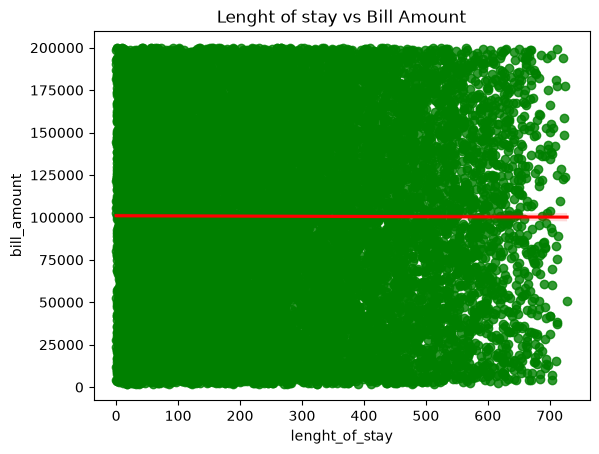

In [72]:
sns.regplot(
    data=df,
    x='lenght_of_stay',
    y='bill_amount',
    scatter_kws={'color':'green'},
    line_kws={'color':'red'}
)
plt.title('Lenght of stay vs Bill Amount')
plt.show()
        

In [75]:
np.mean(df['bill_amount'])


np.float64(100716.90062521432)

In [76]:
np.median(df['bill_amount']),


(np.float64(100044.505),)

In [77]:
np.std(df['bill_amount'])

np.float64(57617.76078130879)

In [78]:
np.percentile(
    df['bill_amount'],
    [25,50,75]
)

array([ 50677.6675, 100044.505 , 151204.3075])